In [295]:
import numpy as np
from sympy.abc import k
import sympy as sp
from sympy import MatMul
from scipy.optimize import root_scalar
from matplotlib import pyplot as plt
import pandas as pd

#
3.2

In [66]:
# entrada
def entrada_1(amostra, M: int = 7):

    fase = (2 * sp.pi) / M
    return sp.cos(fase * amostra)


def entrada(amostra, M: int = 7):

    fase = (2 * np.pi) / M
    return np.cos(fase * amostra)


def referencia_1(amostra, M: int = 7):

    fase = (2 * sp.pi) / M
    return sp.sin(amostra * fase)


def referencia(amostra, M: int = 7):

    fase = (2 * np.pi) / M
    return np.sin(amostra * fase)


def erro(
    referencia: list | np.ndarray, peso: list | np.ndarray, entrada: list | np.ndarray
):
    peso = np.asarray(peso)
    referencia = np.asarray(referencia)
    entrada = np.asarray(entrada)

    return referencia - peso.T * entrada


# iterações
iter = 1500

In [57]:
# Matriz Correlaçao
# R = [[0.5, 0.311745], [0.311745, 0.5]] # gabarito

# R = E[x * x.T]


def func_matriz_correlacao(ordem_filtro=1):
    """para filtro de 1 ordem.

    X = [
        entrada(amostras),
        entrada(amostras - 1),
        entrada(amostras - 2),
        ...
        ]
    """

    # O +1 é por causa da funçao range que ignora o ultimo valor
    X = [[entrada_1(k - k1)] for k1 in range(ordem_filtro + 1)]
    X = sp.Matrix(X)

    return X @ X.T


R = func_matriz_correlacao(ordem_filtro=1)
R.applyfunc(sp.Function("E"))

Matrix([
[                   E(cos(2*pi*k/7)**2), E(cos(2*pi*k/7)*cos(pi*(2*k/7 - 2/7)))],
[E(cos(2*pi*k/7)*cos(pi*(2*k/7 - 2/7))),            E(cos(pi*(2*k/7 - 2/7))**2)]])

Comentários do aluno:

- O elemento a11 representa a potencia do sinal.  

- Considerando um processo estacionário, temos que os elementos da diagonal principal são iguais, a11 = a22.  
(essa afirmação veremos na prática)  

- A diagonal secundária também é igual, já que a matriz R é simétrica.  

- Como as diagonais da matriz R são iguais e ela é composta de versões do msm sinal com atrasos, pode-se dizer que R é uma matriz Toeplitz.  


- Para cada item de R, será calculada um valor média com 7 amostras (já que M=7)


In [72]:
amostras = [0, 1, 2, 3, 4, 5, 6]
R_aux = []

for r in R:
    aux = 0

    for i in amostras:
        aux += r.subs(k, i)

    R_aux.append([(aux / len(amostras)).evalf(5)])

matriz_correlacao = sp.Matrix(R_aux).reshape(2, 2)
print("Matriz de correlacao R:")
matriz_correlacao

Matriz de correlacao R:


Matrix([
[    0.5, 0.31174],
[0.31174,     0.5]])

Aqui vemos que a matriz se comportou como esperado, portanto é seguro dizer que R é, de fato, Toeplitz.

In [70]:
# Calculo do vetor de correlação cruzada (cross-correlation vector)
# p = [0, 0.390916]  # gabarito


def cross_correlation(ordem_filtro):
    # p = [Expectation(referencia(k) * entrada(k)), Expectation(referencia(k) * entrada(k))]
    X = [[referencia_1(k) * entrada_1(k - k1)] for k1 in range(ordem_filtro + 1)]
    return sp.Matrix(X)


p = cross_correlation(1)
p.applyfunc(sp.Function("E"))

Matrix([
[        E(sin(2*pi*k/7)*cos(2*pi*k/7))],
[E(sin(2*pi*k/7)*cos(pi*(2*k/7 - 2/7)))]])

Comentários do aluno:

- Pela ortogonalidade entre seno e cosseno, o valor esperado de a11 é 0.  
- 


In [87]:
# amostras = [0, 1, 2, 3, 4, 5, 6]
p_aux = []

for P in p:
    aux = 0

    for i in amostras:
        aux += P.subs(k, i)

    p_aux.append([(aux / len(amostras)).evalf(5)])

vetor_correlacao_cruzada = sp.Matrix(p_aux).reshape(2, 1)
print("Vetor de correlacao cruzada p:")
vetor_correlacao_cruzada

Vetor de correlacao cruzada p:


Matrix([
[      0],
[0.39092]])

In [90]:
# coefficients of Wiener solution

# tratamento dos dados
matriz_correlacao = np.array(matriz_correlacao, dtype=float)
vetor_correlacao_cruzada = np.array(vetor_correlacao_cruzada, dtype=float)


w0 = np.linalg.pinv(matriz_correlacao) @ vetor_correlacao_cruzada
sp.Matrix(w0)

Matrix([
[-0.797472426705588],
[  1.27904733013332]])

Comentários do aluno:
- Os resultados deram certinhos

#
3.6

Enunciado

An adaptive filtering algorithm is used to identify a system with impulse response given below:  

  h = [0.1, 0.3, 0, -0.2, -0.4, -0.7, -0.4, -0.2].T    

Consider three cases for the input signal: colored noises with variance σ²ₓ = 1 and eigenvalue spread of their correlation matrix equal to 1.0, 20, and 80, respectively. The measurement noise is Gaussian white noise, uncorrelated with the input, and with variance σ²ₙ = 10⁻⁴. The adaptive filter has eight coefficients.

(a) Run the algorithm and comment on the convergence behavior in each case.

(b) Measure the misadjustment in each example and compare it with the theoretical results where appropriate.

(c) Considering that fixed-point arithmetic is used, run the algorithm for a set of experiments and calculate the expected values for ||w(k)Q||² and ξ(k)Q for the following case:

    Additional noise: white noise with variance σ²ₙ = 0.0015
    Coefficient word length: bc = 16 bits
    Signal word length: bd = 16 bits
    Input signal: Gaussian white noise with variance σ²ₓ = 1.0

(d) Repeat the previous experiment for the following cases:

    bc = 12 bits, bd = 12 bits
    bc = 10 bits, bd = 10 bits

(e) Suppose the unknown system is a time-varying system whose coefficients are first-order Markov processes with λw = 0.99 and σ²w = 0.0015. The initial time-varying system multiplier coefficients are the ones described above. The input signal is Gaussian white noise with variance σ²ₓ = 1.0, and the measurement noise is also Gaussian white noise independent of the input signal and of the elements of nw(k), with variance σ²ₙ = 0.01.

Simulate the experiment described, measure the total excess MSE, and compare it to the calculated results.

Considerações:  

1. Ruido colorido com variancia σ = 1.  
2. Ruido de medição é Gaussian e branco com variancia σ = 10**-4 sem relação com a entrada.  
3. eigenvalue spread = λ_min / λ_max  
4. Filtro de 1ª ordem

Considere tres valores/casos para o eigenvalue spread do sinal de entrada:  
1. 1  
2. 20  
3. 80  

In [ ]:
# resposta ao impulso
h = [0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2]

In [276]:
# Matriz de correlação

a = sp.Symbol("a")
sigma_v2 = sp.Symbol(r"sigma_v^2")

sigma_n2 = 1e-4  # variancia do ruido de medição

E_x2 = sigma_v2 / (1 - a**2)
# print("Valor esperado da potência do sinal de entrada:")
# display(E_x2)

# print("\nMatriz de correlação para filtro de 8ª ordem:")
R = sp.Matrix(8, 8, lambda i, j: a ** abs(i - j))
# display(R)

In [262]:
expr = MatMul(E_x2, R, evaluate=False)
print("Matriz de correlação para esse sinal de entrada:")
display(expr)

Matriz de correlação para esse sinal de entrada:


(sigma_v^2/(1 - a**2))*Matrix([
[   1,    a, a**2, a**3, a**4, a**5, a**6, a**7],
[   a,    1,    a, a**2, a**3, a**4, a**5, a**6],
[a**2,    a,    1,    a, a**2, a**3, a**4, a**5],
[a**3, a**2,    a,    1,    a, a**2, a**3, a**4],
[a**4, a**3, a**2,    a,    1,    a, a**2, a**3],
[a**5, a**4, a**3, a**2,    a,    1,    a, a**2],
[a**6, a**5, a**4, a**3, a**2,    a,    1,    a],
[a**7, a**6, a**5, a**4, a**3, a**2,    a,    1]])

In [ ]:
"Funçao para obter o valor de a para cada um dos casos apresentados (1,20,80)"


def achando_valor_de_a(spread_desejado):
    f = lambda a_num: (
        np.linalg.eigvalsh(
            np.array([[a_num ** abs(i - j) for j in range(8)] for i in range(8)])
        )[-1]
        / np.linalg.eigvalsh(
            np.array([[a_num ** abs(i - j) for j in range(8)] for i in range(8)])
        )[0]
        - spread_desejado
    )

    a = root_scalar(f, bracket=[0, 0.999], method="brentq").root

    print(f"a para spread = 1.0 : {a:.5f}")
    return a

In [265]:
# Valores de a
a_values = []
for s in [1, 20, 80]:
    aux = achando_valor_de_a(s)
    a_values.append(aux)

a para spread = 1.0 : 0.00000
a para spread = 1.0 : 0.68940
a para spread = 1.0 : 0.87019


In [266]:
# Autovalores de cada matriz

matriz_autovalores_a01 = np.array(
    [[a_values[0] ** abs(i - j) for j in range(8)] for i in range(8)]
)
autovalores_a01 = np.linalg.eigvalsh(matriz_autovalores_a01)

matriz_autovalores_a20 = np.array(
    [[a_values[1] ** abs(i - j) for j in range(8)] for i in range(8)]
)
autovalores_a20 = np.linalg.eigvalsh(matriz_autovalores_a20)


matriz_autovalores_a80 = np.array(
    [[a_values[2] ** abs(i - j) for j in range(8)] for i in range(8)]
)
autovalores_a80 = np.linalg.eigvalsh(matriz_autovalores_a80)


print(
    f"Autovalores:\n\n {autovalores_a01 = } \n\n {autovalores_a20 = } \n\n {autovalores_a80 = }"
)

Autovalores:

 autovalores_a01 = array([1., 1., 1., 1., 1., 1., 1., 1.]) 

 autovalores_a20 = array([0.19054869, 0.21260353, 0.25717152, 0.34177355, 0.51003694,
       0.88143592, 1.7954561 , 3.81097376]) 

 autovalores_a80 = array([0.07209411, 0.08101539, 0.09943055, 0.13586289, 0.21447512,
       0.42151305, 1.20808021, 5.76752867])


Os autovalores para eigenvalue_spread=1 é a mattriz identidade, o que é esperado já q a=0  


In [271]:
# Definição da taxa de aprendizado para cada caso

mu_max_01 = 2 / max(autovalores_a01)
tx_01 = mu_max_01 / 5


mu_max_20 = 2 / max(autovalores_a20)
tx_20 = mu_max_20 / 5


mu_max_80 = 2 / max(autovalores_a80)
tx_80 = mu_max_80 / 5


tx_01, tx_20, tx_80

(np.float64(0.4),
 np.float64(0.10496005089706936),
 np.float64(0.06935379479037027))

In [ ]:
#  Funçao do filtro LMS


def LMS(
    h,
    a,
    sigma_n2=1e-4,
    ordem_filtro=8,
    taxa_aprendizado=0.02,
    numero_amostras=2000,
):
    """
    LMS para identificação de sistemas.

    Parameters
    ----------
    h : ndarray
        Sistema desconhecido.
    a : float
        Coeficiente do processo AR(1).
    sigma_n2 : float
        Variância do ruído de medição.
    ordem_filtro : int
        Número de coeficientes do filtro adaptativo.
    taxa_aprendizado : float
        Passo do LMS.
    numero_amostras : int
        Número de amostras da simulação.

    Returns
    -------
    erro_quadratico : ndarray
        e²(k), usado nas Fig. 3.8 e 3.9.
    historico_pesos : ndarray
        Evolução temporal dos coeficientes.
    entrada : ndarray
        Sinal de entrada gerado.
    valor_desejado : ndarray
        Sinal desejado gerado.
    """

    # Geração do sinal
    sigma_v2 = 1 - a**2
    ruido_branco = np.sqrt(sigma_v2) * np.random.randn(numero_amostras)
    entrada = np.zeros(numero_amostras)

    for k in range(1, numero_amostras):
        entrada[k] = a * entrada[k - 1] + ruido_branco[k]

    # Geração do sinal desejado
    ruido_medicao = np.sqrt(sigma_n2) * np.random.randn(numero_amostras)
    valor_desejado = np.convolve(entrada, h)[:numero_amostras] + ruido_medicao

    # LMS

    pesos = np.zeros(ordem_filtro)

    erro_quadratico = np.zeros(numero_amostras)

    historico_pesos = np.zeros((numero_amostras, ordem_filtro))

    for k in range(ordem_filtro, numero_amostras):

        vetor_entrada = entrada[k : k - ordem_filtro : -1]

        saida_filtro = pesos @ vetor_entrada

        erro = valor_desejado[k] - saida_filtro

        pesos += taxa_aprendizado * erro * vetor_entrada

        erro_quadratico[k] = erro**2

        historico_pesos[k] = pesos

    return (
        erro_quadratico,
        historico_pesos,
        entrada,
        valor_desejado,
    )

In [248]:
# Funçao para plot


def plot_learning_curve(
    erro_quadratico,
    spread=None,
    a=None,
    sigma_n2=1e-4,
    janela_suavizacao=20,
    titulo="Curva de Aprendizagem do LMS",
):
    """
    Plota a curva de aprendizagem do LMS.

    Parameters
    ----------
    erro_quadratico : ndarray
        Vetor e²(k) retornado pelo LMS.

    spread : float, opcional
        Eigenvalue spread utilizado.

    a : float, opcional
        Valor de a utilizado na geração do sinal.

    sigma_n2 : float
        Variância do ruído de medição.

    janela_suavizacao : int ou None
        Tamanho da média móvel.
        Exemplo: 25, 50, 100.
        Se None, plota o sinal original.

    titulo : str
        Título do gráfico.
    """

    curva = np.asarray(erro_quadratico).copy()

    # Evita log(0)
    curva[curva <= 0] = np.finfo(float).eps

    if janela_suavizacao is not None:

        curva = np.convolve(
            curva,
            np.ones(janela_suavizacao) / janela_suavizacao,
            mode="valid",
        )

    eixo_x = np.arange(len(curva))

    plt.figure(figsize=(12, 8))

    legenda = "LMS"

    if spread is not None and a is not None:
        legenda += f" (Spread={spread}, a={a:.5f})"

    plt.plot(
        eixo_x,
        10 * np.log10(curva),
        linewidth=2,
        label=legenda,
    )

    plt.axhline(
        10 * np.log10(sigma_n2),
        linestyle="--",
        linewidth=1.5,
        label=rf"Piso de ruído ($\sigma_n^2={sigma_n2}$)",
    )

    plt.title(
        titulo,
        fontsize=14,
        fontweight="bold",
    )

    plt.xlabel(
        "Número de iterações, $k$",
        fontsize=12,
    )

    plt.ylabel(
        r"$10\log_{10}(e^2(k))$ [dB]",
        fontsize=12,
    )

    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

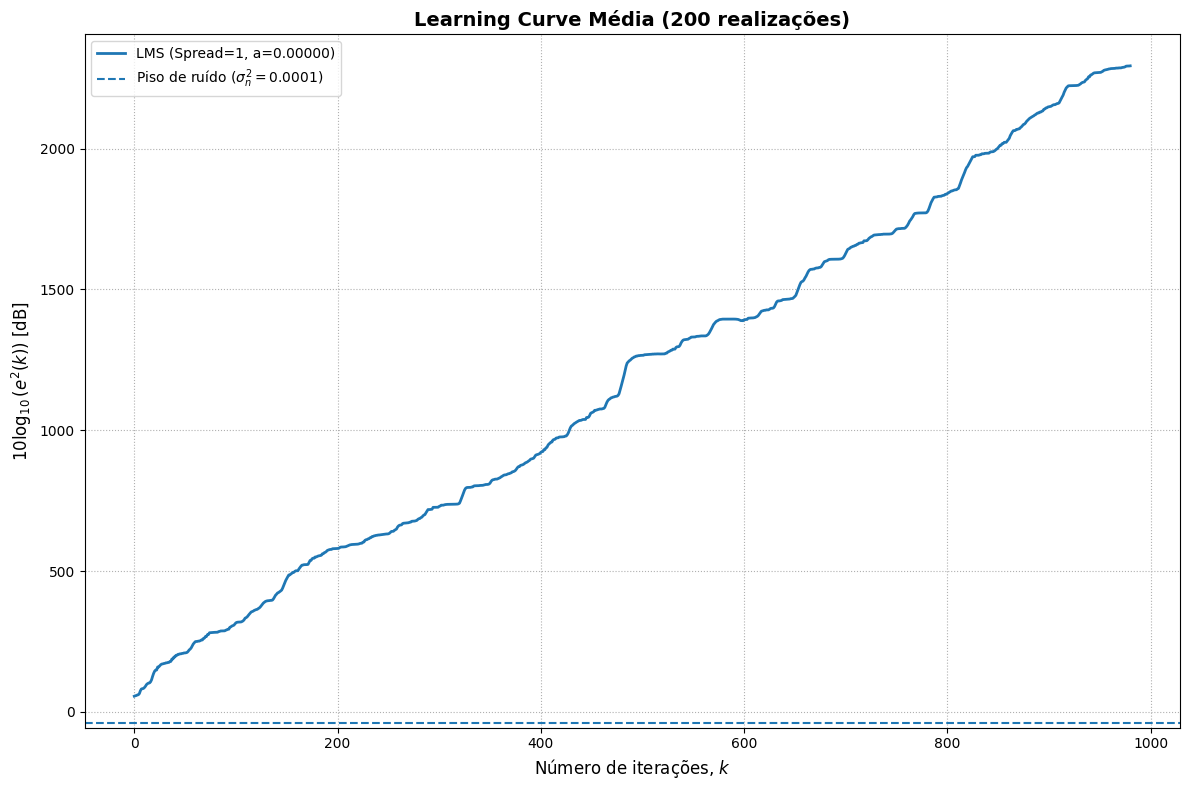

In [272]:
# CASO 01
# Curva de aprendizado para spread=1
amostras = 1000
mse_medio_01_1 = np.zeros(amostras)

for _ in range(200):

    erro_quadratico, *_ = LMS(
        h=h,
        a=a_values[0],
        taxa_aprendizado=tx_01,
        numero_amostras=amostras,
    )

    mse_medio_01_1 += erro_quadratico

mse_medio_01_1 /= 200

plot_learning_curve(
    mse_medio_01_1,
    spread=1,
    a=a_values[0],
    titulo="Learning Curve Média (200 realizações)",
)

A resposta acima é inesperada já que a taxa de aprendizado foi calculada de acordo com os passos mostrados no livro do Diniz. Em comparação aos valores achados pelo autor, os aqui calculados estão em uma ordem de 10x maior. Não se sabe o motivo da discrepância, contudo será testado o valor aqui calculado divido por 10

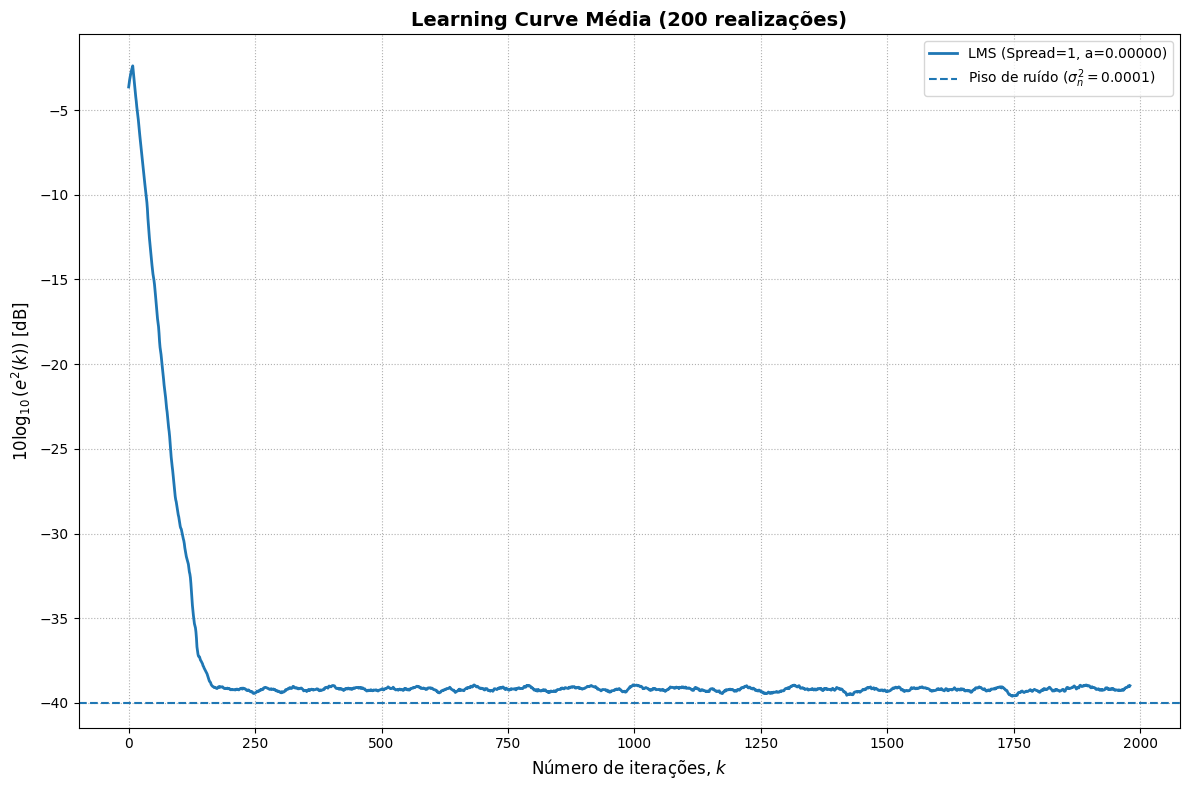

In [278]:
# CASO 01 (segunda tentativa)
# Curva de aprendizado para spread=1

amostras = 2000
mse_medio_01 = np.zeros(amostras)

for _ in range(200):

    erro_quadratico_01, *_ = LMS(
        h=h,
        a=a_values[0],
        taxa_aprendizado=tx_01 / 10,  # correção do mi
        numero_amostras=amostras,
    )

    mse_medio_01 += erro_quadratico_01

mse_medio_01 /= 200

plot_learning_curve(
    mse_medio_01,
    spread=1,
    a=a_values[0],
    titulo="Learning Curve Média (200 realizações)",
)

Agora, com o valor ajustado, o resultado deu de acordo com o esperado. Uma curva decrescente que estabiliza em -40dB.  
A reta crescente anterior mostrava que o filtro não estava aprendendo os pesos corretos. Isso se deve a taxa de aprendizado muito grande, onde a cada iteração o algoritmo dava "passos" grandes demais e fez com que divergisse.


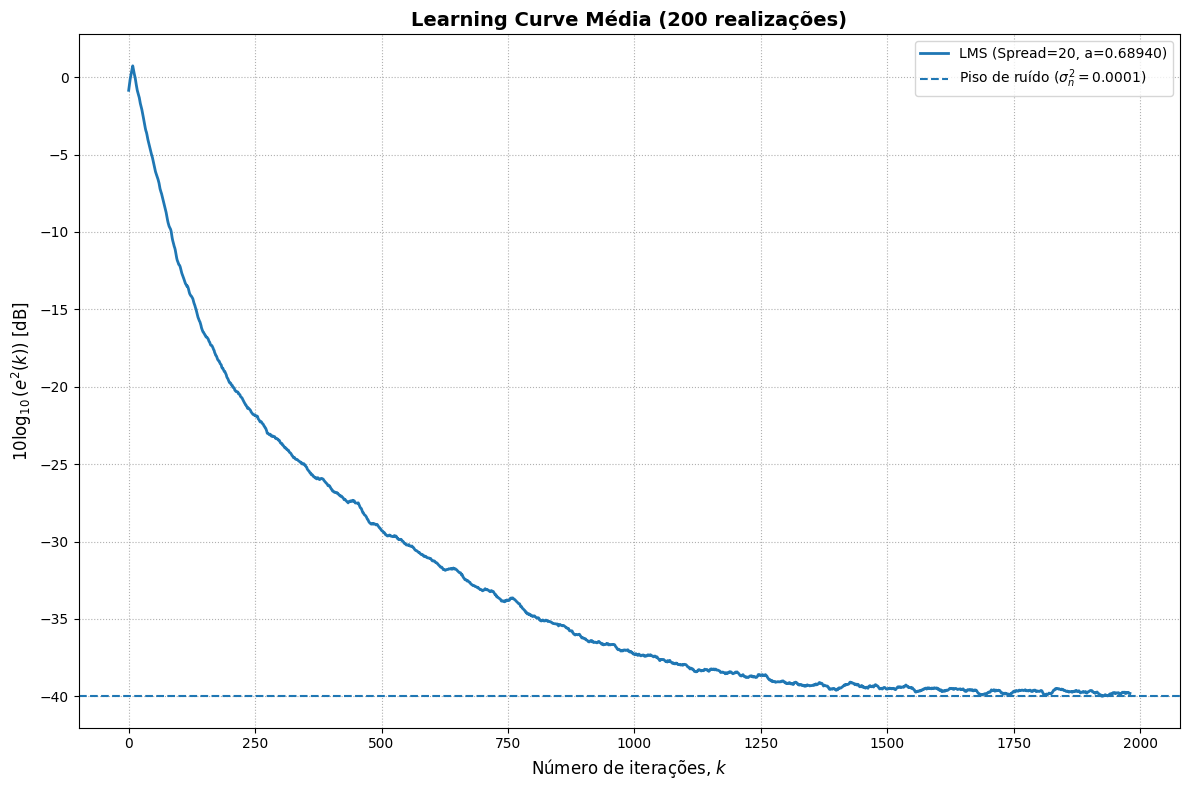

In [279]:
# CASO 02
# Curva de aprendizado para spread=20

amostras = 2000
mse_medio_20 = np.zeros(amostras)

for _ in range(200):

    erro_quadratico_20, *_ = LMS(
        h=h,
        a=a_values[1],
        taxa_aprendizado=tx_20 / 10,  # correção do mi
        numero_amostras=amostras,
    )

    mse_medio_20 += erro_quadratico_20

mse_medio_20 /= 200

plot_learning_curve(
    mse_medio_20,
    spread=20,
    a=a_values[1],
    titulo="Learning Curve Média (200 realizações)",
)

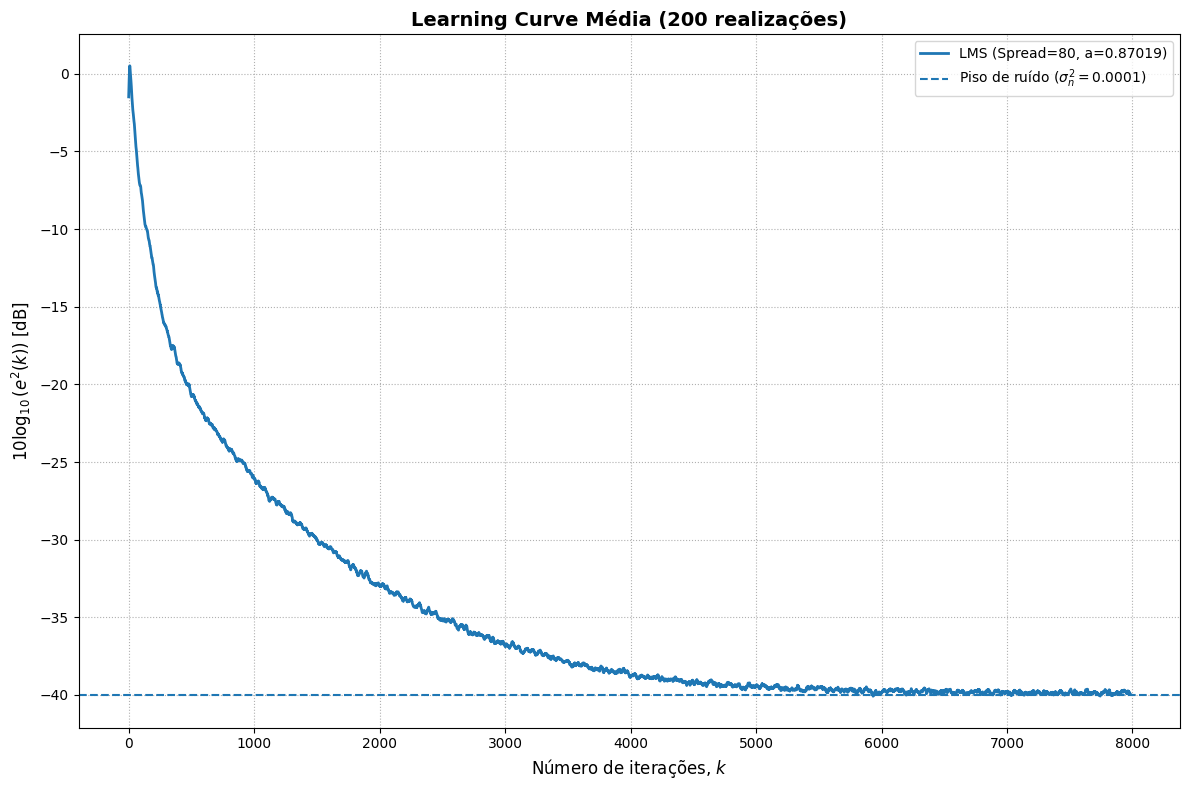

In [287]:
# CASO 03
# Curva de aprendizado para spread=80

amostras = 2000 * 4
realizacoes = 200

mse_medio_80 = np.zeros(amostras)

for _ in range(realizacoes):

    erro_quadratico_80, *_ = LMS(
        h=h,
        a=a_values[2],
        taxa_aprendizado=tx_80 / 10,  # correção do mi
        numero_amostras=amostras,
    )

    mse_medio_80 += erro_quadratico_80

mse_medio_80 /= realizacoes

plot_learning_curve(
    mse_medio_80,
    spread=80,
    a=a_values[2],
    titulo=f"Learning Curve Média ({realizacoes} realizações)",
)

Nota-se que nos casos 1 e 2 o valor é estabilizado em -40dB ante das 2mil amostras. Sendo o caso 1 o que converge mais rápido (em aproximadamente 250 amostras). O caso 3 nao atingiu a estabilidade de erro mesmo depois do triplo de amostras. Foi necessário o quadruplo de amostras para a estabilização.  

Isso mostra que a taxa de aprendizado junto ao valor de a calculado fazem com que a convergencia seja lenta ou rapida ou até mesmo que nnão acontecça, como visto no inicio.

Fim da letra a

---------

LETRA B)

Como o ruido de medição é de 1e-4, o erro de Wiener tem o mesmo valor já q filtros nao tiram esse tipo de ruido

In [290]:
# Caso 01

J_inf = np.mean(mse_medio_01[-500:])  # MSE em regime permanente

misadjustment_01 = (J_inf - sigma_n2) / sigma_n2

print(f"J_inf = {J_inf:.6e}")
print(f"Misadjustment = {misadjustment_01:.6f}")
print(f"Misadjustment (%) = {100*misadjustment_01:.2f}%")

J_inf = 1.201061e-04
Misadjustment = 0.201061
Misadjustment (%) = 20.11%


In [291]:
# Caso 02

J_inf = np.mean(mse_medio_20[-500:])  # MSE em regime permanente

misadjustment_20 = (J_inf - sigma_n2) / sigma_n2

print(f"J_inf = {J_inf:.6e}")
print(f"Misadjustment_20 = {misadjustment_20:.6f}")
print(f"Misadjustment_20 (%) = {100*misadjustment_20:.2f}%")

J_inf = 1.082323e-04
Misadjustment_20 = 0.082323
Misadjustment_20 (%) = 8.23%


In [293]:
# Caso 03

J_inf = np.mean(mse_medio_80[-500:])  # MSE em regime permanente

misadjustment_80 = (J_inf - sigma_n2) / sigma_n2

print(f"J_inf = {J_inf:.6e}")
print(f"Misadjustment_80 = {misadjustment_80:.6f}")
print(f"Misadjustment_80 (%) = {100*misadjustment_80:.2f}%")

J_inf = 1.034749e-04
Misadjustment_80 = 0.034749
Misadjustment_80 (%) = 3.47%


In [307]:
tabela = pd.DataFrame(
    {
        "Caso #": [1, 20, 80],
        "a": a_values,
        "μ": [tx_01 / 10, tx_20 / 10, tx_80 / 10],
        "M_teórico": [
            tx_01 / 10 * 8 / 2,
            tx_20 / 10 * 8 / 2,
            tx_80 / 10 * 8 / 2,
        ],
        "M_simulado": [
            misadjustment_01,
            misadjustment_20,
            misadjustment_80,
        ],
    }
)

tabela["Erro (%)"] = (
    abs(tabela["M_simulado"] - tabela["M_teórico"]) / tabela["M_teórico"] * 100
)

display(
    tabela.style.format(
        {
            "a": "{:.4f}",
            "μ": "{:.5f}",
            "M_teórico": "{:.4f}",
            "M_simulado": "{:.4f}",
            "Erro (%)": "{:.2f}",
        }
    )
)

,Caso #,a,μ,M_teórico,M_simulado,Erro (%)
0,1,0.0000,0.04000,0.1600,0.2011,25.66
1,20,0.6894,0.01050,0.0420,0.0823,96.08
2,80,0.8702,0.00694,0.0277,0.0347,25.26


Os valores de M_teorico foram multiplicados por 8/2 para a aproximação do misadjustment do LMS. 

M ≈ μ*tr(R) / 2

onde:
μ = taxa de aprendizado;
tr(R) = traço da matriz de correlação.


Para os casos 1 e 3 (de espalhamento unitário e espalhamento de 80), os valores simulados apresentaram erros relativos de aproximadamente 25% em relação à previsão teórica. Apesar da discrepância, ambos os resultados permanecem da mesma ordem de grandeza, indicando que a aproximação teórica é razoável para esse cenário.  


No caso 2, de spread = 20, foi observada um erro relativo de 96%. Esse resultado indica que as simplificações adotadas na obtenção da expressão teórica podem perder precisão se certas condições não forem atendidas. Além disso, a formulação clássica do misadjustment assume valores reduzidos de μ, o que pode não ter sido atendido na simulação.


Os valores das taxas de aprendizado obtidos a partir de tx=mi_max/5 resultaram em curvas de aprendizagem divergentes. Para reproduzir resultados compatíveis com os apresentados no livro, foi necessária uma redução adicional de 10x na taxa. Isso evidencia que o limite teórico de estabilidade serve como norte/ponto de partida, não como gabarito/solução.

---------------------

Letras C e D

In [ ]:
# PARÂMETROS
N = len(h)
MU = 0.01
SIGMA_X2 = 1.0
SIGMA_N2 = 1e-4
SIGMA_E2 = 0.0015

K = 2000
RUNS = 200


# ERRO %
def erro_percentual(exp, teo):
    return np.abs((exp - teo) / teo) * 100


# QUANTIZAÇÃO
def quantize(x, bits):
    delta = 2.0 / (2**bits)
    xq = np.round(x / delta) * delta
    return np.clip(xq, -1, 1 - delta)


# LMS EM PONTO FIXO
def lms_fixed(bits_data, bits_coef):

    w = np.zeros(N)

    mse = np.zeros(K)
    dw = np.zeros(K)

    x = np.sqrt(SIGMA_X2) * np.random.randn(K + N)
    n = np.sqrt(SIGMA_N2) * np.random.randn(K)

    for k in range(K):

        # ---------------------------
        # vetor de entrada
        # ---------------------------
        u = x[k : k + N][::-1]

        # quantização de entrada
        u_q = quantize(u, bits_data)

        # ---------------------------
        # saída desejada (modelo real)
        # ---------------------------
        d = h @ u_q + n[k]
        d_q = quantize(d, bits_data)

        # ---------------------------
        # saída do filtro
        # ---------------------------
        y = w @ u_q
        y_q = quantize(y, bits_data)

        # ---------------------------
        # erro quantizado
        # ---------------------------
        e = d_q - y_q
        e_q = quantize(e, bits_data)

        # ---------------------------
        # atualização LMS
        # ---------------------------
        w = w + MU * e_q * u_q

        # quantização dos coeficientes
        w = quantize(w, bits_coef)

        # ---------------------------
        # métricas
        # ---------------------------
        mse[k] = e_q**2
        dw[k] = np.dot(h - w, h - w)

    return mse, dw


# Gerando dados e aplicando o LMS
def main(bits):

    mse_avg = np.zeros(K)
    dw_avg = np.zeros(K)

    for _ in range(RUNS):

        mse, dw = lms_fixed(bits, bits)

        mse_avg += mse
        dw_avg += dw

    return mse_avg / RUNS, dw_avg / RUNS


# EXECUÇÃO
mse16, dw16 = main(16)
mse12, dw12 = main(12)
mse10, dw10 = main(10)


# RESULTADOS EM REGIME PERMANENTE
tail = 1000  # pegando os ultumos termos

mse10_exp = np.mean(mse10[-tail:])
mse12_exp = np.mean(mse12[-tail:])
mse16_exp = np.mean(mse16[-tail:])

dw10_exp = np.mean(dw10[-tail:])
dw12_exp = np.mean(dw12[-tail:])
dw16_exp = np.mean(dw16[-tail:])

print("\nRESULTADOS REGIME PERMANENTE\n")


# RESULTADOS TEÓRICOS


def theoretical_results(bits):

    mu = 0.01  # valor usado no livro

    delta = 2.0 / (2**bits)
    sigma_w2 = delta**2 / 12

    den = 1 - mu * (N + 1) * SIGMA_X2

    termo_aditivo = (N + 1) * sigma_w2 / (4 * mu * SIGMA_X2 * den)

    dw_th = (mu * (SIGMA_E2 + SIGMA_N2) * (N + 1)) / den
    dw_th += termo_aditivo

    xi_th = (SIGMA_E2 + SIGMA_N2) / den
    xi_th += termo_aditivo

    return dw_th, xi_th


# RESULTADOS TEÓRICOS
dw10_teo, xi10_teo = theoretical_results(10)
dw12_teo, xi12_teo = theoretical_results(12)
dw16_teo, xi16_teo = theoretical_results(16)


print("\n================ RESULTADOS =================\n")

for b, mse_e, dw_e, mse_t, dw_t in [
    (16, mse16_exp, dw16_exp, xi16_teo, dw16_teo),
    (12, mse12_exp, dw12_exp, xi12_teo, dw12_teo),
    (10, mse10_exp, dw10_exp, xi10_teo, dw10_teo),
]:

    print(f"{b} bits")
    print(f"MSE exp = {mse_e:.6f}")
    print(f"MSE teo = {mse_t:.6f}")
    print(f"DW  exp = {dw_e:.6f}")
    print(f"DW  teo = {dw_t:.6f}")
    print("-" * 40)


RESULTADOS REGIME PERMANENTE


================ RESULTADOS =================

16 bits
MSE exp = 0.000209
MSE teo = 0.001758
DW  exp = 0.000542
DW  teo = 0.000158
----------------------------------------
12 bits
MSE exp = 0.000268
MSE teo = 0.001763
DW  exp = 0.000782
DW  teo = 0.000163
----------------------------------------
10 bits
MSE exp = 0.002060
MSE teo = 0.001837
DW  exp = 0.008164
DW  teo = 0.000237
----------------------------------------


In [391]:
print("\n================ ERRO PERCENTUAL =================\n")

for b, mse_e, mse_t, dw_e, dw_t in [
    (16, mse16_exp, xi16_teo, dw16_exp, dw16_teo),
    (12, mse12_exp, xi12_teo, dw12_exp, dw12_teo),
    (10, mse10_exp, xi10_teo, dw10_exp, dw10_teo),
]:

    err_mse = erro_percentual(mse_e, mse_t)
    err_dw = erro_percentual(dw_e, dw_t)

    print(f"{b} bits")
    print(f"Erro MSE = {err_mse:.2f}%")
    print(f"Erro DW  = {err_dw:.2f}%")
    print("-" * 40)


================ ERRO PERCENTUAL =================

16 bits
Erro MSE = 88.10%
Erro DW  = 242.42%
----------------------------------------
12 bits
Erro MSE = 84.77%
Erro DW  = 379.12%
----------------------------------------
10 bits
Erro MSE = 12.13%
Erro DW  = 3346.92%
----------------------------------------


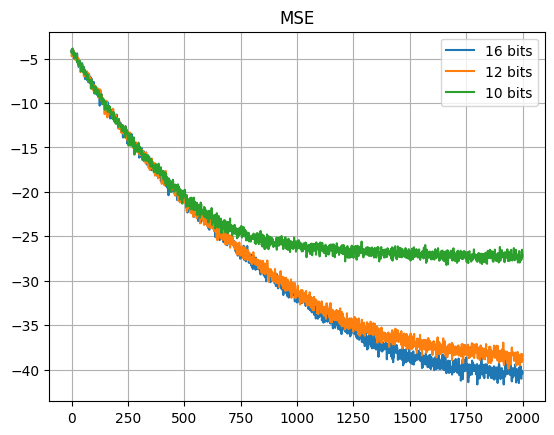

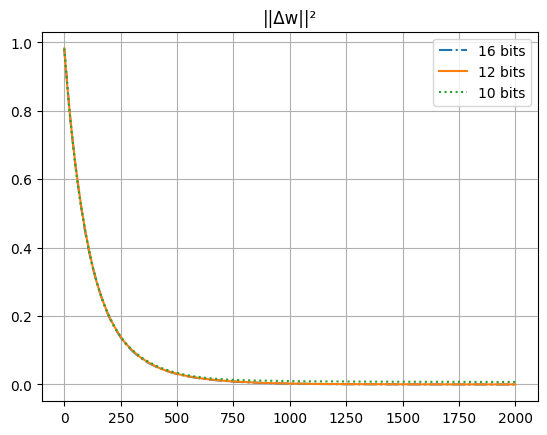

In [386]:
# PLOT
plt.figure()
plt.plot(10 * np.log10(mse16), label="16 bits")
plt.plot(10 * np.log10(mse12), label="12 bits")
plt.plot(10 * np.log10(mse10), label="10 bits")
plt.legend()
plt.grid()
plt.title("MSE")

plt.figure()
plt.plot(dw16, label="16 bits", linestyle="-.")
plt.plot(dw12, label="12 bits", linestyle="-")
plt.plot(dw10, label="10 bits", linestyle=":")
plt.legend()
plt.grid()
plt.title("||Δw||²")

plt.show()


Apesar de os resultados apresentarem convergência do algoritmo LMS, observa-se uma diferença significativa entre os valores experimentais e teóricos, refletida nos elevados erros percentuais obtidos. Em especial, o erro associado aos coeficientes apresenta maior discrepância.

Essa divergência pode estar relacionada à forma como a aritmética de ponto fixo foi aproximada na implementação. Em sistemas de precisão finita, todos os sinais passam por quantização após cada operação. Pequenas variações nesse processo podem se acumular ao longo das iterações e impactar significativamente o desempenho do algoritmo.

Além disso, o modelo de quantização uniforme utilizado na simulação não capturou completamente todos os efeitos práticos de um sistema em ponto fixo, como saturação e acúmulo de erro numérico, apesar das toda as tentativas. Somado ao caráter estocástico do algoritmo e ao uso de um número finito de realizações, esses fatores contribuem para as diferenças observadas entre os resultados experimentais e teóricos.
